<a href="https://colab.research.google.com/github/sugamthapa47/SugamThapa_INFO4670_Spring2026/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# Install required packages if needed
# !pip install pandas matplotlib mlxtend networkx

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('bread_basket.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Unique transactions: {df['transaction'].nunique()}")
print(f"Unique items: {df['item'].nunique()}")
df.head()

Dataset loaded successfully!
Shape: (20507, 6)
Unique transactions: 9465
Unique items: 94


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


In [29]:
# a) Variables and their data types
print("Column Names and Data Types:")
print("-" * 35)
print(df.dtypes)
print(f"\nTotal rows   : {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Unique transactions: {df['transaction'].nunique()}")
print(f"Unique items       : {df['item'].nunique()}")

Column Names and Data Types:
-----------------------------------
transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object

Total rows   : 20507
Total columns: 6
Unique transactions: 9465
Unique items       : 94


In [30]:
# b) Statistical overview of all columns
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


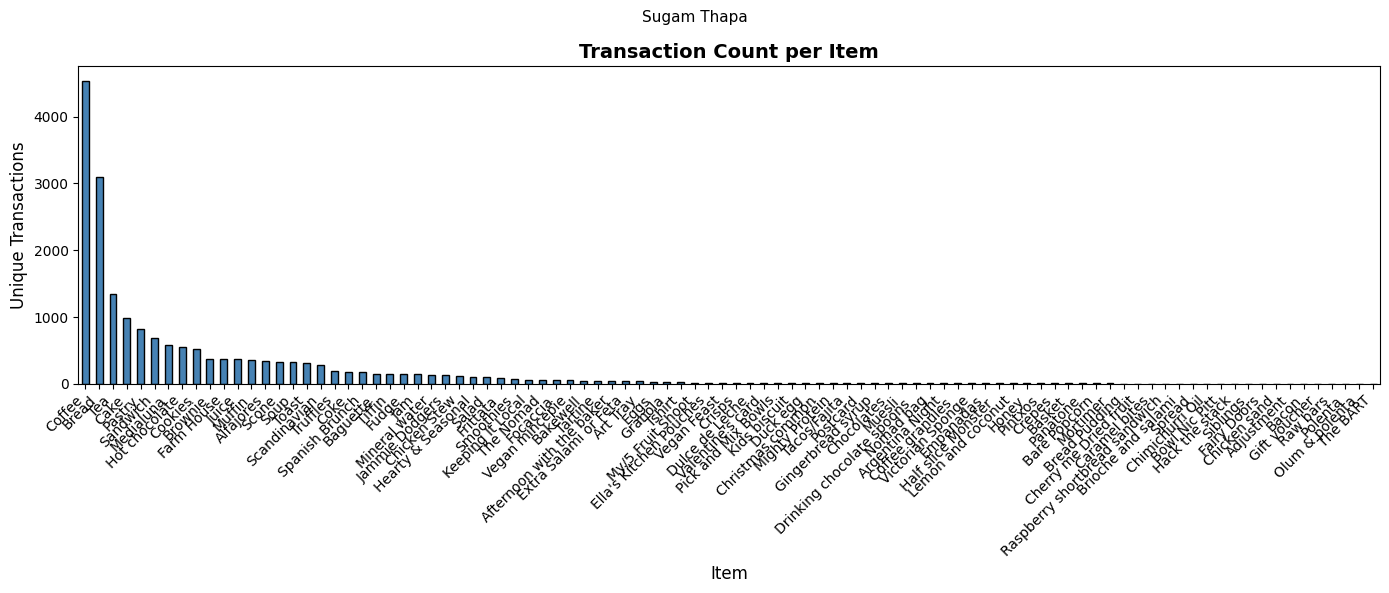


Top 5 items by transaction count:
item
Coffee    4528
Bread     3097
Tea       1350
Cake       983
Pastry     815
Name: transaction, dtype: int64


In [31]:
# c) Bar plot of unique transaction counts per item
subtitle = "Sugam Thapa"
item_counts = (
    df.groupby('item')['transaction']
    .nunique()
    .sort_values(ascending=False)
)

ax = item_counts.plot(kind='bar', figsize=(14, 6), color='steelblue', edgecolor='black')
plt.title(f"Transaction Count per Item", fontsize=14, fontweight='bold')
plt.suptitle(subtitle, fontsize=11, y=0.98)
plt.xlabel("Item", fontsize=12)
plt.ylabel("Unique Transactions", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTop 5 items by transaction count:")
print(item_counts.head())

In [32]:
# d) Unique transaction counts for selected items
selected_items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']

counts = (
    df[df['item'].isin(selected_items)]
    .groupby('item')['transaction']
    .nunique()
    .reindex(selected_items)
)

result_df = pd.DataFrame({
    'Item': selected_items,
    'Unique Transactions': counts.values
})

print("Selected Item Transaction Counts:")
print("-" * 38)
print(result_df.to_string(index=False))

Selected Item Transaction Counts:
--------------------------------------
        Item  Unique Transactions
      Coffee                 4528
         Tea                 1350
   Alfajores                  344
       Juice                  365
Chicken Stew                  123


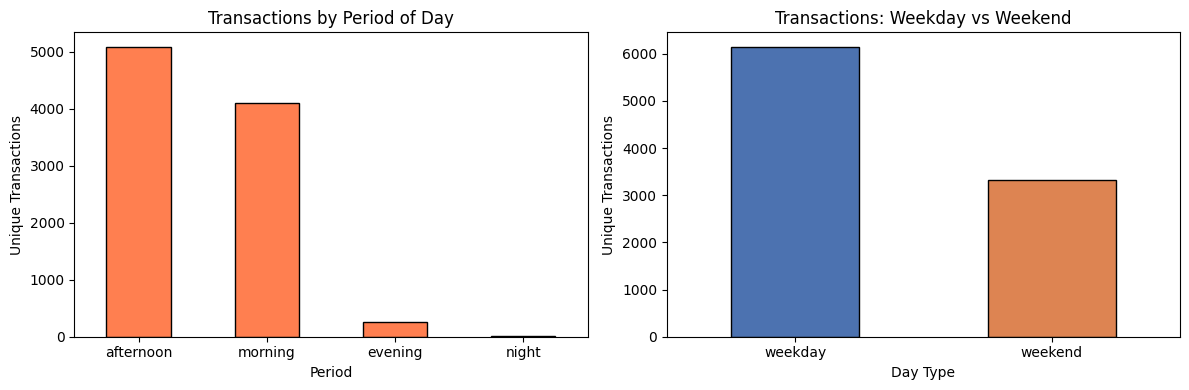

In [33]:
# e) Period of day and weekday vs weekend distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

period_counts = df.groupby('period_day')['transaction'].nunique().sort_values(ascending=False)
period_counts.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Transactions by Period of Day')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Unique Transactions')
axes[0].tick_params(axis='x', rotation=0)

week_counts = df.groupby('weekday_weekend')['transaction'].nunique()
week_counts.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452'], edgecolor='black')
axes[1].set_title('Transactions: Weekday vs Weekend')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Unique Transactions')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [34]:
# Step 1: Build transaction x item one-hot boolean matrix
basket = (
    df.groupby(['transaction', 'item'])['item']
    .count()
    .unstack(fill_value=0)
    .map(lambda x: True if x > 0 else False)
)

print(f"One-hot basket shape: {basket.shape}")
print(f"  → {basket.shape[0]} transactions × {basket.shape[1]} unique items")
basket.head()

One-hot basket shape: (9465, 94)
  → 9465 transactions × 94 unique items


item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
transaction,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [35]:
# Step 2: Run FP-Growth with min_support = 0.02
freq_itemsets = fpgrowth(basket, min_support=0.02, use_colnames=True)
freq_itemsets['itemset_size'] = freq_itemsets['itemsets'].apply(len)
freq_sorted = freq_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f"Total frequent itemsets found: {len(freq_itemsets)}")
print(f"  1-itemsets: {(freq_itemsets['itemset_size']==1).sum()}")
print(f"  2-itemsets: {(freq_itemsets['itemset_size']==2).sum()}")
print(f"  3-itemsets: {(freq_itemsets['itemset_size']==3).sum()}")
print()
print("Top 15 Frequent Itemsets:")
freq_sorted[['support','itemsets','itemset_size']].head(15)

Total frequent itemsets found: 33
  1-itemsets: 19
  2-itemsets: 14
  3-itemsets: 0

Top 15 Frequent Itemsets:


,support,itemsets,itemset_size
0,0.478394,(Coffee),1
1,0.327205,(Bread),1
2,0.142631,(Tea),1
3,0.103856,(Cake),1
4,0.090016,"(Coffee, Bread)",2
5,0.086107,(Pastry),1
6,0.071844,(Sandwich),1
7,0.061807,(Medialuna),1
8,0.058320,(Hot chocolate),1
9,0.054728,"(Coffee, Cake)",2


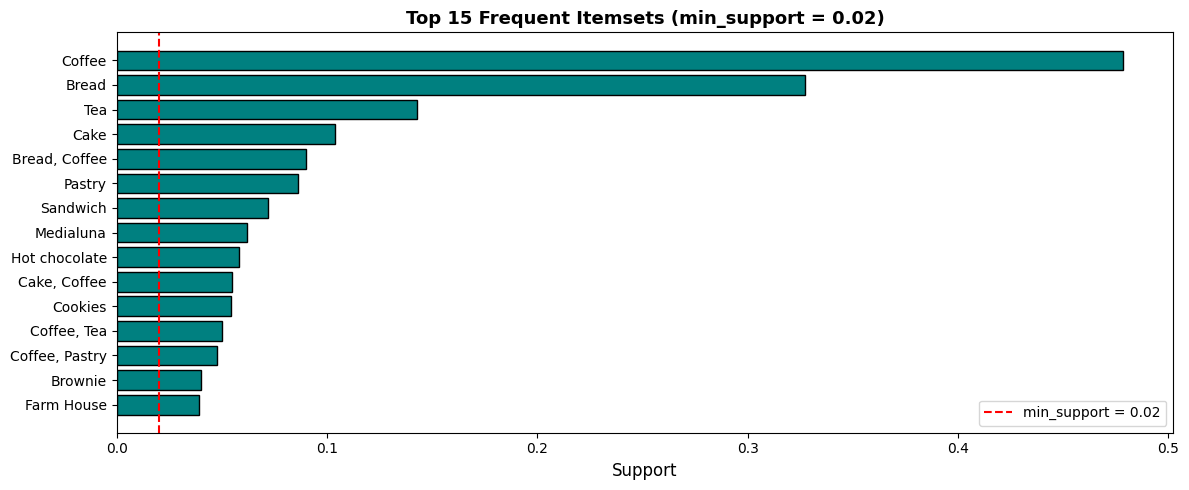

In [36]:
# Visualise support of top frequent itemsets
top15 = freq_sorted.head(15).copy()
top15['label'] = top15['itemsets'].apply(lambda x: ', '.join(sorted(x)))

plt.figure(figsize=(12, 5))
plt.barh(top15['label'][::-1], top15['support'][::-1], color='teal', edgecolor='black')
plt.xlabel('Support', fontsize=12)
plt.title('Top 15 Frequent Itemsets (min_support = 0.02)', fontsize=13, fontweight='bold')
plt.axvline(x=0.02, color='red', linestyle='--', label='min_support = 0.02')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Generate association rules
min_threshold = 0.3

rules = association_rules(
    freq_itemsets,
    metric='confidence',
    min_threshold=min_threshold
)

# Clean up for display
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

report = (
    rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
    .sort_values('lift', ascending=False)
    .reset_index(drop=True)
)
report.columns = ['Antecedents', 'Consequents', 'Support', 'Confidence', 'Lift']
report[['Support','Confidence','Lift']] = report[['Support','Confidence','Lift']].round(4)

print(f"Total association rules generated: {len(rules)}")
print(f"(metric=confidence, min_threshold={min_threshold})\n")
report

Total association rules generated: 10
(metric=confidence, min_threshold=0.3)



,Antecedents,Consequents,Support,Confidence,Lift
0,Toast,Coffee,0.0237,0.7044,1.4724
1,Medialuna,Coffee,0.0352,0.5692,1.1899
2,Pastry,Coffee,0.0475,0.5521,1.1542
3,Juice,Coffee,0.0206,0.5342,1.1167
4,Sandwich,Coffee,0.0382,0.5324,1.1128
5,Cake,Coffee,0.0547,0.5270,1.1015
6,Cookies,Coffee,0.0282,0.5184,1.0837
7,Hot chocolate,Coffee,0.0296,0.5072,1.0603
8,Pastry,Bread,0.0292,0.3387,1.0350
9,Tea,Coffee,0.0499,0.3496,0.7308


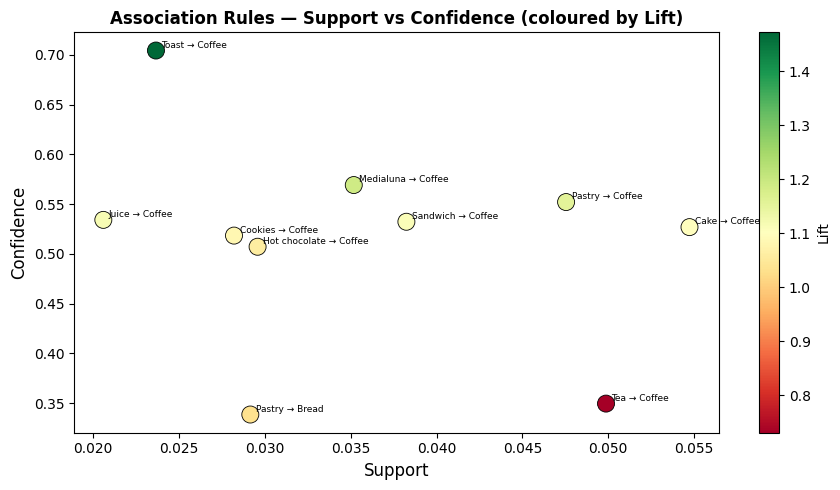

In [38]:
# Scatter plot: Support vs Confidence, coloured by Lift
plt.figure(figsize=(9, 5))
sc = plt.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', s=150, edgecolors='black', linewidths=0.6
)
plt.colorbar(sc, label='Lift')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Association Rules — Support vs Confidence (coloured by Lift)', fontsize=12, fontweight='bold')

for _, row in rules.iterrows():
    label = f"{row['antecedents_str']} → {row['consequents_str']}"
    plt.annotate(label, (row['support'], row['confidence']),
                 fontsize=6.5, xytext=(4, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

Rules involving {Bread, Coffee, Cake, Tea}: 10


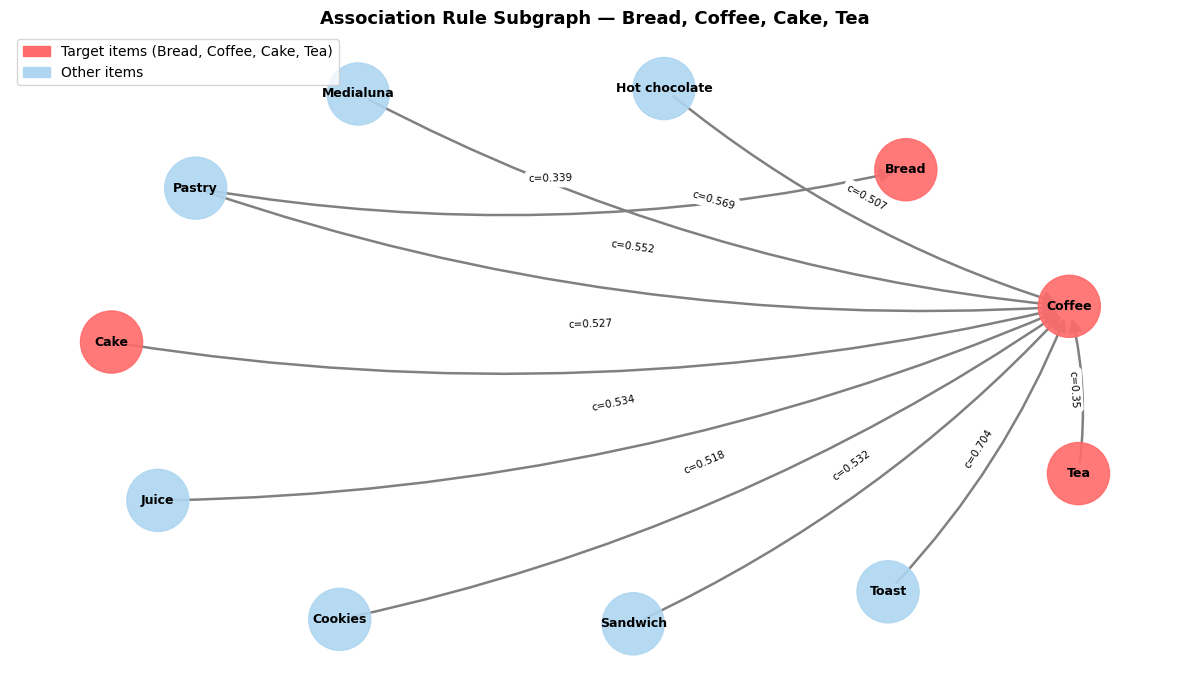

In [39]:
# Filter and draw subgraph for target items
target_items = {'Bread', 'Coffee', 'Cake', 'Tea'}

def involves_any_target(rule_row):
    combined = rule_row['antecedents'] | rule_row['consequents']
    return bool(combined & target_items)

sub_rules = rules[rules.apply(involves_any_target, axis=1)].copy()
print(f"Rules involving {{Bread, Coffee, Cake, Tea}}: {len(sub_rules)}")

# Build directed graph
G = nx.DiGraph()
for _, row in sub_rules.iterrows():
    a = row['antecedents_str']
    c = row['consequents_str']
    G.add_node(a); G.add_node(c)
    G.add_edge(a, c, confidence=round(row['confidence'], 3), lift=round(row['lift'], 3))

pos = nx.spring_layout(G, seed=42, k=2.5)
node_colors = ['#FF6B6B' if n in target_items else '#AED6F1' for n in G.nodes()]
edge_labels = {(u, v): f"c={d['confidence']}" for u, v, d in G.edges(data=True)}

plt.figure(figsize=(12, 7))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowsize=20, width=1.8,
                       edge_color='gray', arrows=True, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7.5)

red_patch = mpatches.Patch(color='#FF6B6B', label='Target items (Bread, Coffee, Cake, Tea)')
blue_patch = mpatches.Patch(color='#AED6F1', label='Other items')
plt.legend(handles=[red_patch, blue_patch], loc='upper left')
plt.title('Association Rule Subgraph — Bread, Coffee, Cake, Tea', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [40]:
# Calculate metrics for {Coffee, Cake} => {Bread}
total_transactions = len(basket)

coffee_cake       = basket['Coffee'] & basket['Cake']
coffee_cake_bread = basket['Coffee'] & basket['Cake'] & basket['Bread']

support    = coffee_cake_bread.sum() / total_transactions
confidence = coffee_cake_bread.sum() / coffee_cake.sum()
bread_supp = basket['Bread'].sum() / total_transactions
lift       = confidence / bread_supp

print("Rule: {Coffee, Cake} => {Bread}")
print("=" * 45)
print(f"  Support    : {support:.4f}  ({coffee_cake_bread.sum()} / {total_transactions} transactions)")
print(f"  Confidence : {confidence:.4f}  ({coffee_cake_bread.sum()} / {coffee_cake.sum()} Coffee+Cake baskets)")
print(f"  Lift       : {lift:.4f}")

Rule: {Coffee, Cake} => {Bread}
  Support    : 0.0100  (95 / 9465 transactions)
  Confidence : 0.1834  (95 / 518 Coffee+Cake baskets)
  Lift       : 0.5605
